<a href="https://colab.research.google.com/github/manaskng/Customer_Churn_Prediction_model/blob/main/NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# PART 1: IMPORTING ESSENTIAL LIBRARIES
# ============================================================================

# NumPy: Fundamental package for numerical computing in Python
# Provides support for large multi-dimensional arrays and matrices
import numpy as np

# Pandas: Data manipulation and analysis library
# Provides DataFrame structures for handling structured data
import pandas as pd

# Matplotlib: Comprehensive library for creating static, animated visualizations
import matplotlib.pyplot as plt

# Seaborn: Statistical data visualization built on top of matplotlib
# Provides high-level interface for drawing attractive statistical graphics
import seaborn as sns

# Warnings: Used to suppress unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

# Set visualization style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

# ============================================================================
# PART 2: DATA LOADING AND INITIAL EXPLORATION
# ============================================================================

# pd.read_csv(): Reads CSV file into a pandas DataFrame
# DataFrame: 2D labeled data structure with columns of potentially different types
df = pd.read_csv('Churn_Modelling.csv')

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)

# .head(): Returns first n rows (default=5) for quick dataset preview
print("\nFirst 5 rows of the dataset:")
print(df.head())

# .shape: Returns tuple (rows, columns) representing dataset dimensions
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# .info(): Provides concise summary including:
# - Index dtype and range
# - Column dtypes (data types)
# - Non-null counts
# - Memory usage
print("\nDataset Information:")
print(df.info())

# .describe(): Generates descriptive statistics for numerical columns
# Includes: count, mean, std, min, 25%, 50%, 75%, max
print("\nStatistical Summary:")
print(df.describe())

# .isnull().sum(): Counts missing values per column
# .isnull(): Returns boolean mask where True = missing value
# .sum(): Aggregates True values (True=1, False=0)
print("\nMissing Values per Column:")
print(df.isnull().sum())

# .duplicated().sum(): Counts duplicate rows
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

✓ All libraries imported successfully!

DATASET OVERVIEW

First 5 rows of the dataset:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        1125


EXPLORATORY DATA ANALYSIS

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn Rate: 20.37%


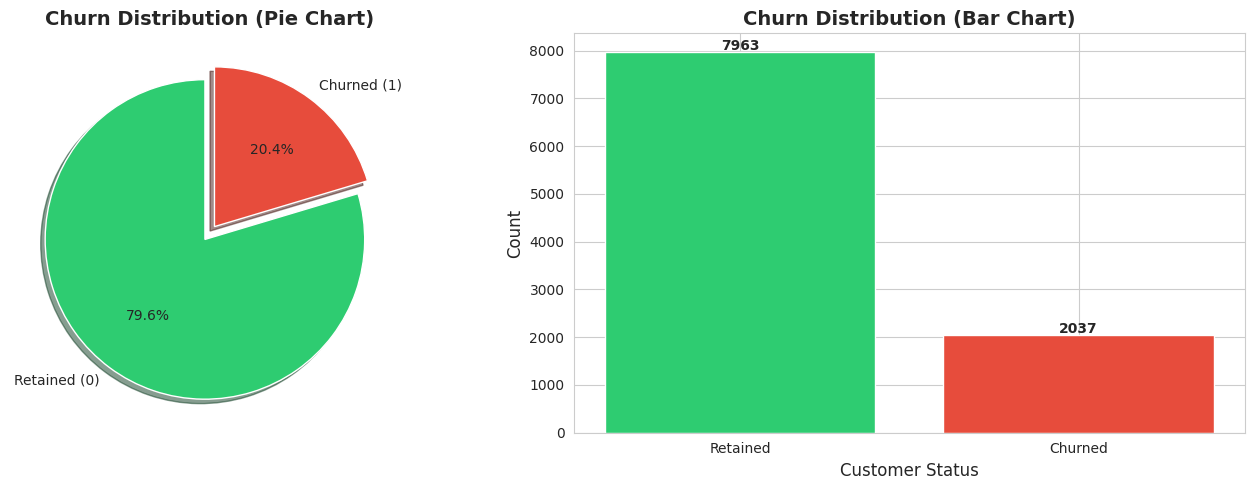

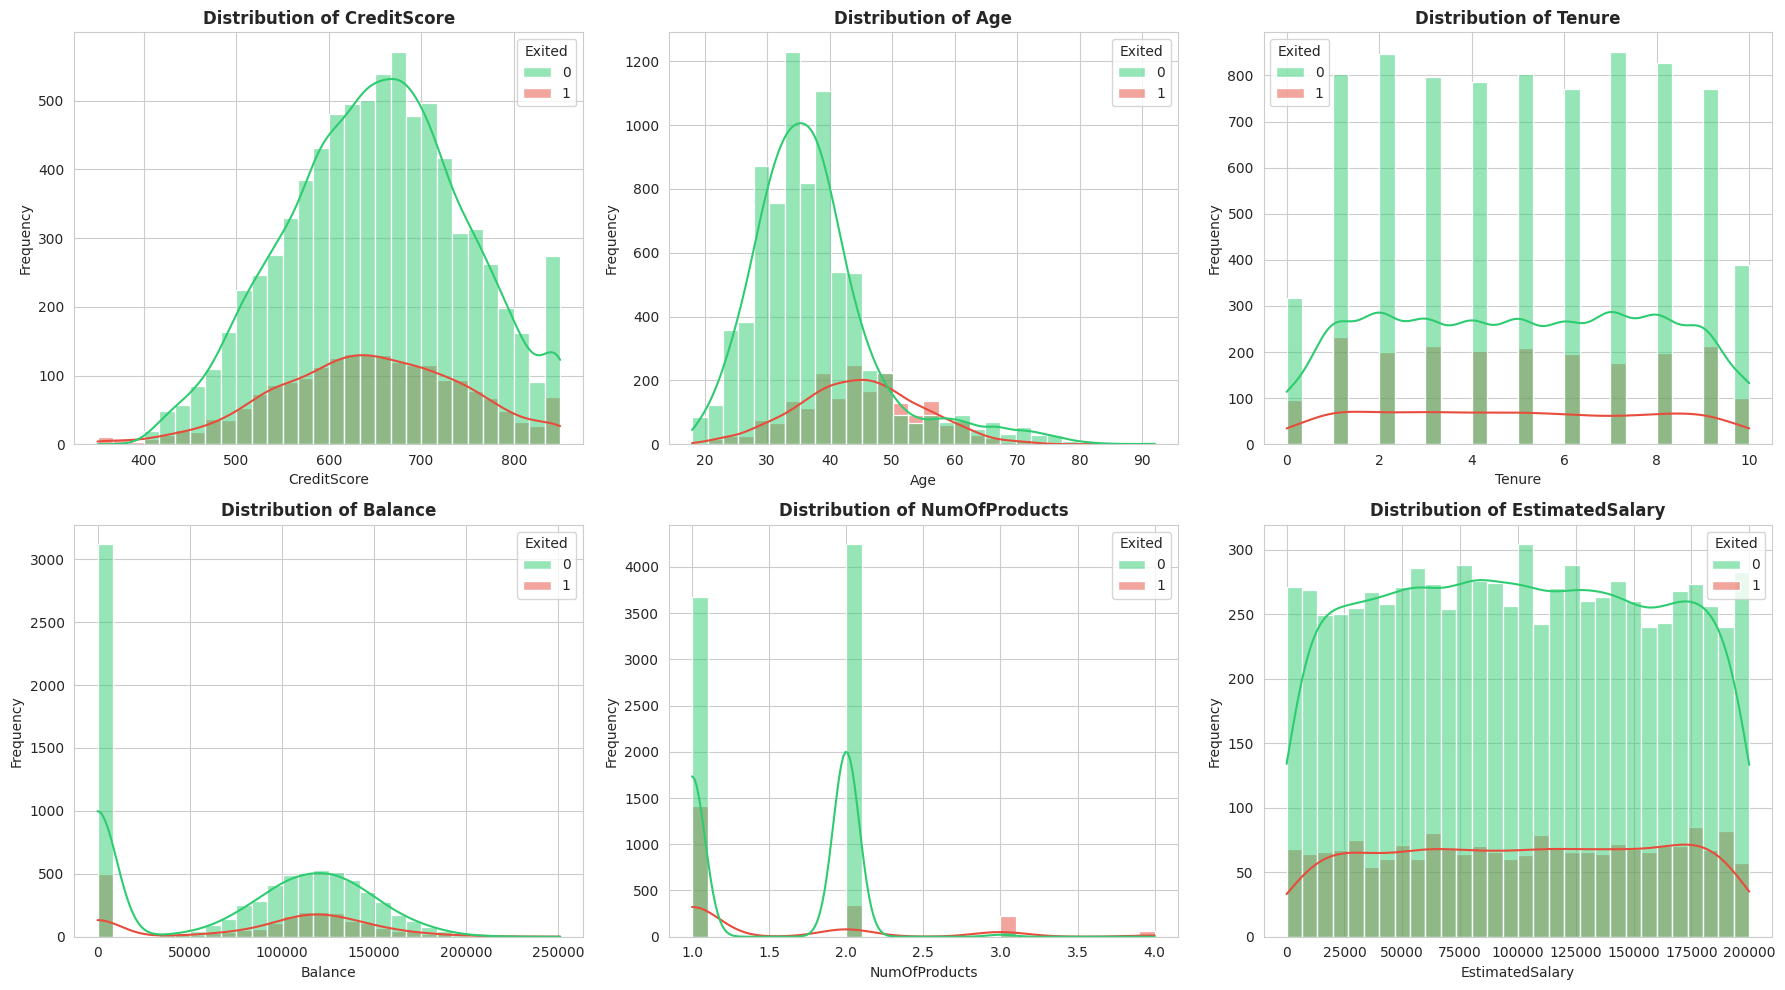

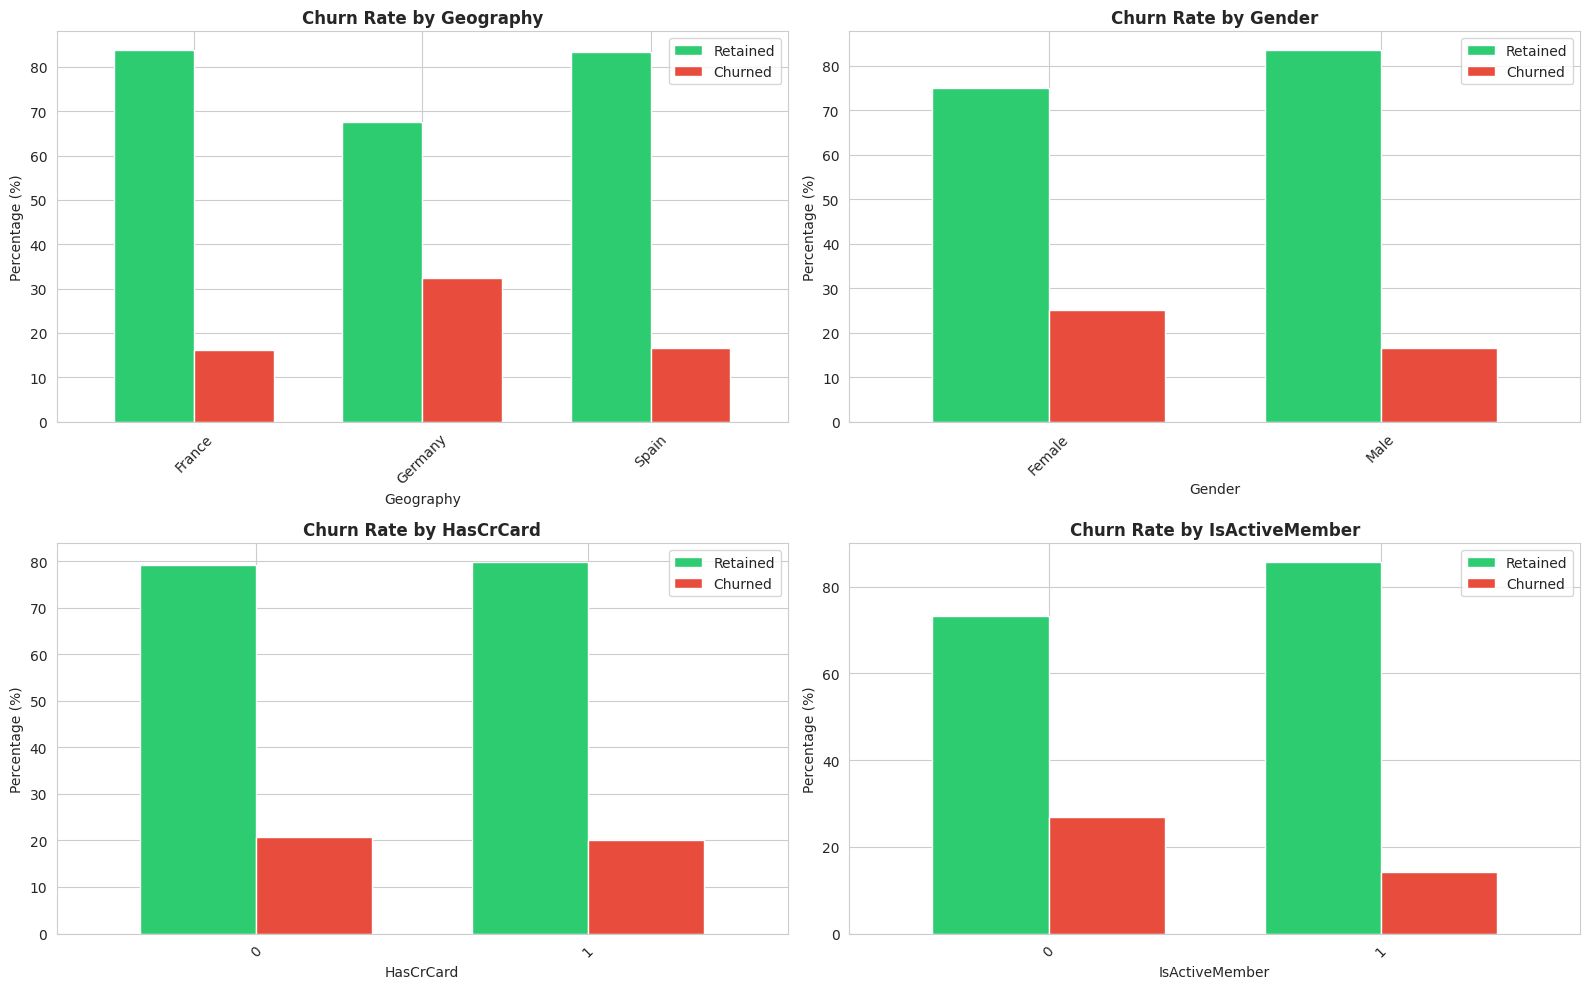

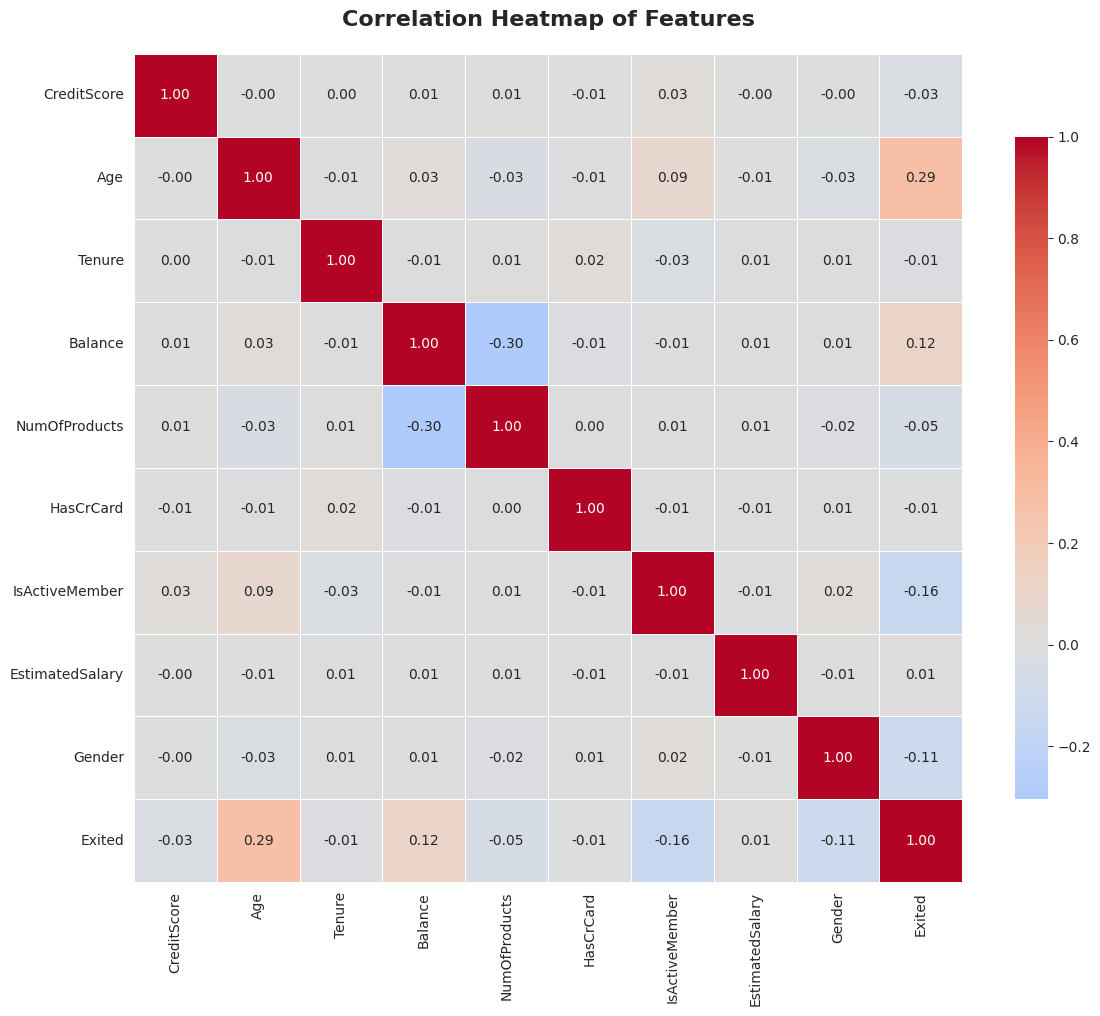


Correlations with Churn (Exited):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Gender            -0.106512
IsActiveMember    -0.156128
Name: Exited, dtype: float64

DATA PREPROCESSING

✓ Dropped columns: ['RowNumber', 'CustomerId', 'Surname']
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Features shape: (10000, 10)
Target shape: (10000,)

✓ Gender encoded using LabelEncoder
Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}

✓ Geography encoded using One-Hot Encoding
New columns created: ['Geography_Germany', 'Geography_Spain']

Final feature set shape: (10000, 11)
Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Estimat

In [2]:
# ============================================================================
# PART 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Target Variable Distribution
# value_counts(): Returns count of unique values in descending order
churn_counts = df['Exited'].value_counts()
print("\nChurn Distribution:")
print(churn_counts)
print(f"Churn Rate: {churn_counts[1]/len(df)*100:.2f}%")

# Visualization 1: Target Variable Distribution (Pie + Bar)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart: Shows proportional distribution
# autopct: String format for percentage labels
# startangle: Rotates start of pie chart
# explode: Separates slices from center
axes[0].pie(churn_counts.values,
            labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0.05, 0.05),
            colors=['#2ecc71', '#e74c3c'],
            shadow=True)
axes[0].set_title('Churn Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Bar Chart: Better for precise value comparison
# .plot(kind='bar'): Creates vertical bar chart
axes[1].bar(['Retained', 'Churned'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xlabel('Customer Status', fontsize=12)

# Add value labels on bars
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Visualization 2: Numerical Features Distribution
# Select only numerical columns for analysis
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                  'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()  # Flatten 2D array to 1D for easy iteration

# Loop through numerical features to create histograms
for idx, col in enumerate(numerical_cols):
    # sns.histplot(): Creates histogram with kernel density estimate (KDE)
    # kde=True: Overlays smooth density curve
    # bins: Number of histogram bars
    sns.histplot(data=df, x=col, hue='Exited', kde=True, bins=30,
                 ax=axes[idx], palette={0: '#2ecc71', 1: '#e74c3c'})
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

# Visualization 3: Categorical Features vs Churn
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    # pd.crosstab(): Computes cross-tabulation of two or more factors
    # normalize='index': Normalizes over rows (percentages per category)
    ct = pd.crosstab(df[col], df['Exited'], normalize='index') * 100

    # Create grouped bar chart
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], width=0.7)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(['Retained', 'Churned'], loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Visualization 4: Correlation Heatmap
# Purpose: Identify relationships between numerical features

# First, encode categorical variables for correlation analysis
df_corr = df.copy()
# map(): Applies function/dictionary to transform values
df_corr['Gender'] = df_corr['Gender'].map({'Female': 0, 'Male': 1})
# get_dummies(): Converts categorical variable into dummy/indicator variables (One-Hot Encoding)
df_corr = pd.get_dummies(df_corr, columns=['Geography'], drop_first=True)

# Select relevant columns for correlation
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender', 'Exited']
corr_cols = [col for col in corr_cols if col in df_corr.columns]

# .corr(): Computes pairwise correlation of columns (Pearson correlation by default)
# Values range from -1 (perfect negative) to +1 (perfect positive)
correlation_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 10))
# sns.heatmap(): Creates color-coded matrix
# annot=True: Displays correlation values in cells
# cmap: Colormap (coolwarm: blue=negative, red=positive)
# fmt='.2f': Format annotations to 2 decimal places
# linewidths: Space between cells
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print strong correlations with target
print("\nCorrelations with Churn (Exited):")
print(correlation_matrix['Exited'].sort_values(ascending=False))

# ============================================================================
# PART 4: DATA PREPROCESSING
# ============================================================================

print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Step 1: Remove irrelevant columns
# RowNumber, CustomerId, Surname don't contribute to prediction
# They are identifiers/metadata, not features
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_processed = df.drop(columns=columns_to_drop)
print(f"\n✓ Dropped columns: {columns_to_drop}")
print(f"Remaining columns: {list(df_processed.columns)}")

# Step 2: Separate Features (X) and Target (y)
# Features: Independent variables used for prediction
# Target: Dependent variable we want to predict
X = df_processed.drop('Exited', axis=1)  # axis=1: drop column
y = df_processed['Exited']  # Target variable

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Step 3: Encode Categorical Variables

# Label Encoding for Gender (Binary categorical variable)
# LabelEncoder: Converts categorical labels to numeric (0, 1, 2, ...)
# Suitable for binary or ordinal categories
from sklearn.preprocessing import LabelEncoder

label_encoder_gender = LabelEncoder()
# fit_transform(): Learns unique values and transforms them
# Female -> 0, Male -> 1 (alphabetical order)
X['Gender'] = label_encoder_gender.fit_transform(X['Gender'])
print("\n✓ Gender encoded using LabelEncoder")
print(f"Mapping: {dict(zip(label_encoder_gender.classes_, label_encoder_gender.transform(label_encoder_gender.classes_)))}")

# One-Hot Encoding for Geography (Nominal categorical with >2 categories)
# pd.get_dummies(): Creates binary columns for each category
# drop_first=True: Prevents multicollinearity by dropping first category
# This avoids the "dummy variable trap" in regression models
X = pd.get_dummies(X, columns=['Geography'], drop_first=True)
print("\n✓ Geography encoded using One-Hot Encoding")
print(f"New columns created: {[col for col in X.columns if 'Geography' in col]}")

print(f"\nFinal feature set shape: {X.shape}")
print(f"Feature columns: {list(X.columns)}")

# Step 4: Split Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split

# train_test_split(): Randomly splits data into training and testing sets
# test_size=0.2: 20% for testing, 80% for training
# random_state=42: Ensures reproducibility (same split every run)
# stratify=y: Maintains same class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✓ Dataset split into train and test sets")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set churn distribution:\n{y_train.value_counts()}")
print(f"\nTesting set churn distribution:\n{y_test.value_counts()}")



FEATURE SCALING COMPARISON

1. STANDARDIZATION (StandardScaler)
   Formula: z = (x - mean) / std
   Training set - Mean: -0.0000, Std: 1.0000
   Range: [-3.1137, 5.0401]

2. NORMALIZATION (MinMaxScaler)
   Formula: x_scaled = (x - min) / (max - min)
   Training set - Min: 0.0000, Max: 1.0000
   Range: [0, 1]

3. ROBUST SCALING (RobustScaler)
   Formula: x_scaled = (x - median) / IQR
   Training set - Median: 0.0000
   Range: [-2.2707, 4.5833]
   Note: More resistant to outliers than StandardScaler


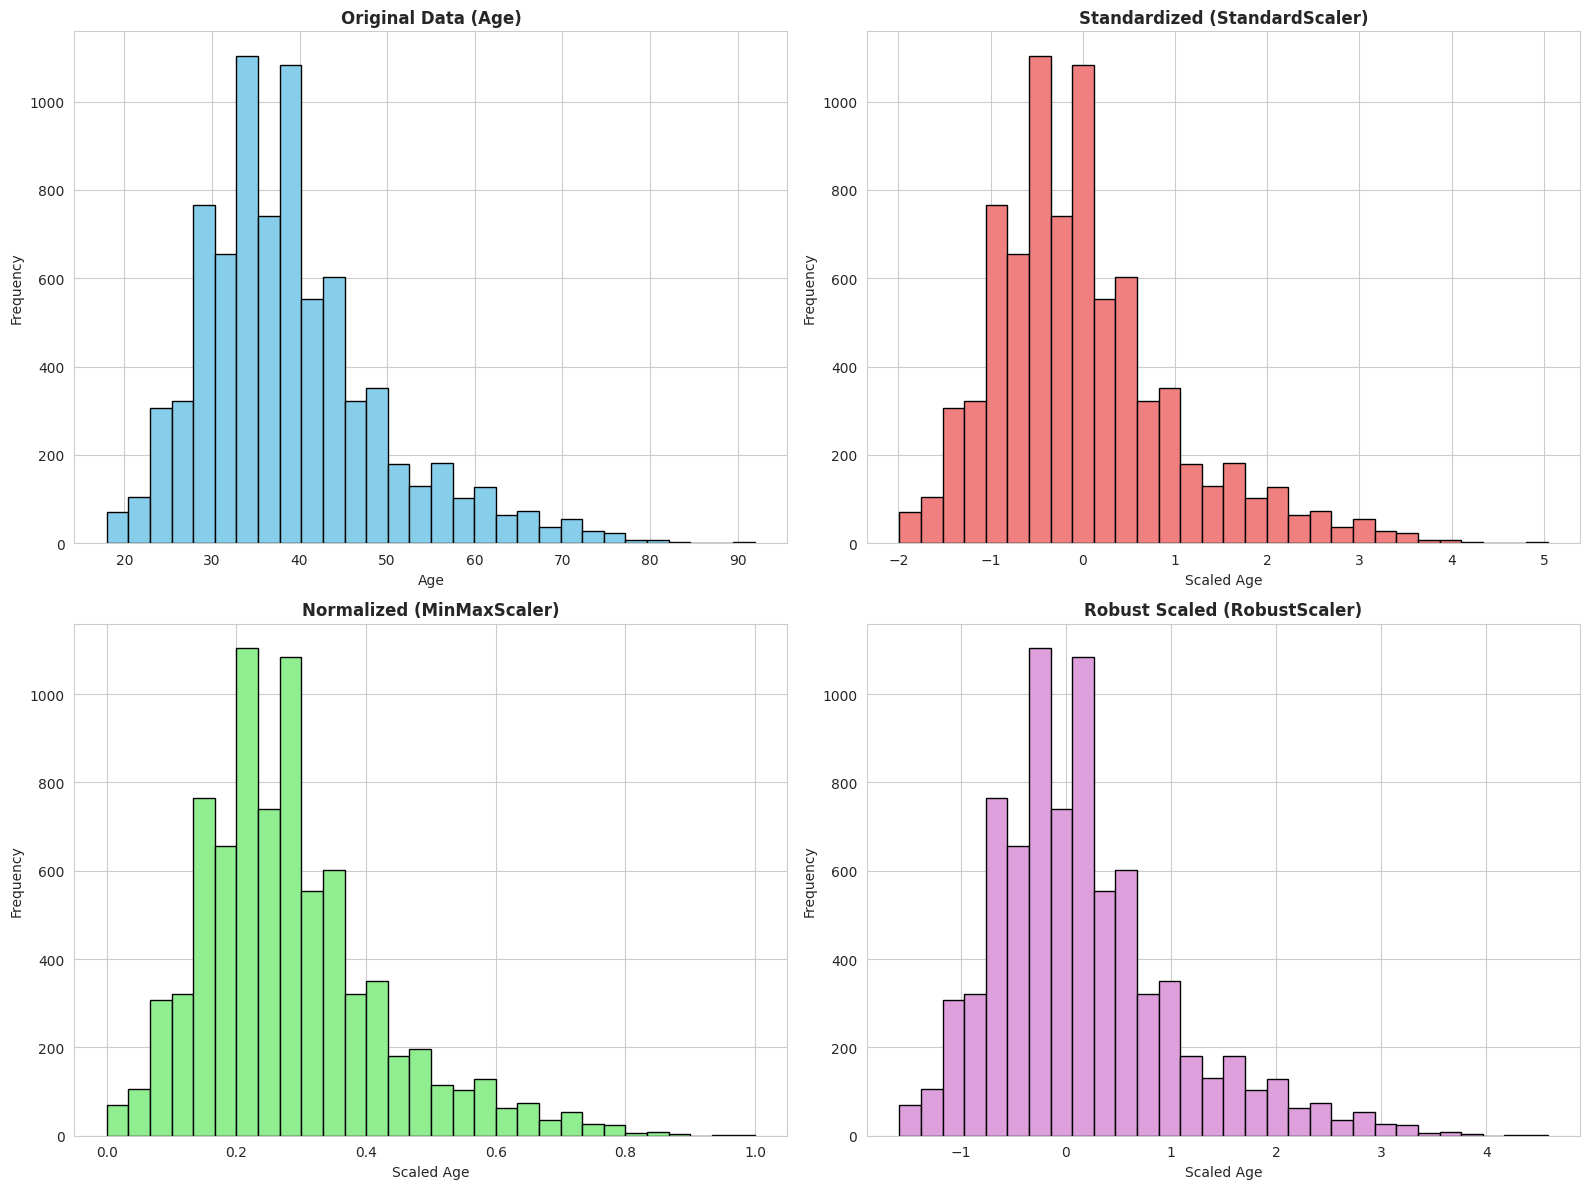


✓ Using StandardScaler for final model


In [3]:
# ============================================================================
# PART 5: FEATURE SCALING (MULTIPLE TECHNIQUES)
# ============================================================================

print("\n" + "="*80)
print("FEATURE SCALING COMPARISON")
print("="*80)

# Feature scaling is CRITICAL for neural networks because:
# 1. Features on different scales can cause gradient descent to converge slowly
# 2. Features with larger values can dominate the learning process
# 3. Activation functions (sigmoid, tanh) work best with normalized inputs

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Technique 1: STANDARDIZATION (StandardScaler)
# Formula: z = (x - μ) / σ
# where μ = mean, σ = standard deviation
# Results in: mean=0, std=1
# Best for: Normally distributed data, when outliers are not a major concern
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)
# fit_transform() on train: learns parameters (mean, std) and transforms
# transform() on test: uses learned parameters (prevents data leakage)

print("\n1. STANDARDIZATION (StandardScaler)")
print(f"   Formula: z = (x - mean) / std")
print(f"   Training set - Mean: {X_train_standard.mean():.4f}, Std: {X_train_standard.std():.4f}")
print(f"   Range: [{X_train_standard.min():.4f}, {X_train_standard.max():.4f}]")

# Technique 2: NORMALIZATION (MinMaxScaler)
# Formula: x_scaled = (x - x_min) / (x_max - x_min)
# Results in: values between 0 and 1
# Best for: When you need bounded values, features with different units
minmax_scaler = MinMaxScaler()
X_train_normalized = minmax_scaler.fit_transform(X_train)
X_test_normalized = minmax_scaler.transform(X_test)

print("\n2. NORMALIZATION (MinMaxScaler)")
print(f"   Formula: x_scaled = (x - min) / (max - min)")
print(f"   Training set - Min: {X_train_normalized.min():.4f}, Max: {X_train_normalized.max():.4f}")
print(f"   Range: [0, 1]")

# Technique 3: ROBUST SCALING (RobustScaler)
# Formula: x_scaled = (x - median) / IQR
# where IQR = Q3 - Q1 (Interquartile Range)
# Results in: median=0, resistant to outliers
# Best for: Data with outliers, non-normal distributions
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

print("\n3. ROBUST SCALING (RobustScaler)")
print(f"   Formula: x_scaled = (x - median) / IQR")
print(f"   Training set - Median: {np.median(X_train_robust):.4f}")
print(f"   Range: [{X_train_robust.min():.4f}, {X_train_robust.max():.4f}]")
print(f"   Note: More resistant to outliers than StandardScaler")

# Visualization: Compare scaling techniques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original data
axes[0, 0].hist(X_train['Age'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Original Data (Age)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Standardized
age_idx = list(X_train.columns).index('Age')
axes[0, 1].hist(X_train_standard[:, age_idx], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Standardized (StandardScaler)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Scaled Age')
axes[0, 1].set_ylabel('Frequency')

# Normalized
axes[1, 0].hist(X_train_normalized[:, age_idx], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Normalized (MinMaxScaler)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Scaled Age')
axes[1, 0].set_ylabel('Frequency')

# Robust Scaled
axes[1, 1].hist(X_train_robust[:, age_idx], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Robust Scaled (RobustScaler)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Scaled Age')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# We'll use StandardScaler for our ANN (most common for neural networks)
X_train_scaled = X_train_standard
X_test_scaled = X_test_standard
scaler = standard_scaler

print("\n✓ Using StandardScaler for final model")


BUILDING ARTIFICIAL NEURAL NETWORK
TensorFlow version: 2.19.0

--------------------------------------------------------------------------------
ACTIVATION FUNCTIONS OVERVIEW
--------------------------------------------------------------------------------

1. ReLU (Rectified Linear Unit): f(x) = max(0, x)
   - Most popular for hidden layers
   - Pros: Simple, fast, helps avoid vanishing gradient
   - Cons: Can suffer from "dying ReLU" problem
   - Use case: Default choice for hidden layers

2. Sigmoid: f(x) = 1 / (1 + e^(-x))
   - Outputs between 0 and 1
   - Pros: Good for binary classification output layer
   - Cons: Vanishing gradient problem, computationally expensive
   - Use case: Binary classification output layer

3. Tanh: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
   - Outputs between -1 and 1
   - Pros: Zero-centered, stronger gradients than sigmoid
   - Cons: Still suffers from vanishing gradient
   - Use case: Hidden layers when zero-centered output is needed

4. Leaky ReLU: f(

Model: "Customer_Churn_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,585 (14.00 KB)

...


Epoch 15: finished saving model to best_churn_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8462 - auc: 0.8339 - loss: 0.3992 - precision: 0.7084 - recall: 0.4229 - val_accuracy: 0.8725 - val_auc: 0.8633 - val_loss: 0.3611 - val_precision: 0.8085 - val_recall: 0.4750 - learning_rate: 0.0010
Epoch 16/100
185/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8397 - auc: 0.8297 - loss: 0.4055 - precision: 0.7081 - recall: 0.4060
Epoch 16: val_auc improved from 0.86332 to 0.86729, saving model to best_churn_model.h5



Epoch 16: finished saving model to best_churn_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8438 - auc: 0.8324 - loss: 0.3983 - precision: 0.7056 - recall: 0.4061 - val_accuracy: 0.8750 - val_auc: 0.8673 - val_loss: 0.3597 - val_precision: 0.8061 - val_recall: 0.4938 - learning_rate: 0.0010
Epoch 17/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8431 - auc: 0.8371 - loss: 0.3989 - precision: 0.7256 - recall: 0.4079
Epoch 17: val_auc did not improve from 0.86729
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8445 - auc: 0.8360 - loss: 0.3962 - precision: 0.7108 - recall: 0.4053 - val_accuracy: 0.8725 - val_auc: 0.8560 - val_loss: 0.3721 - val_precision: 0.8452 - val_recall: 0.4437 - learning_rate: 0.0010
Epoch 18/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8420 - auc: 0.8354 - loss: 0.4024 - precision: 0.7285 - recall: 0.3978
Epoch 18: val_auc did not improve from 0.86729
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8477 - 


Epoch 27: finished saving model to best_churn_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8522 - auc: 0.8500 - loss: 0.3780 - precision: 0.7310 - recall: 0.4397 - val_accuracy: 0.8669 - val_auc: 0.8674 - val_loss: 0.3491 - val_precision: 0.7956 - val_recall: 0.4500 - learning_rate: 5.0000e-04
Epoch 28/100
184/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8553 - auc: 0.8568 - loss: 0.3776 - precision: 0.7691 - recall: 0.4474
Epoch 28: val_auc did not improve from 0.86736
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8572 - auc: 0.8526 - loss: 0.3752 - precision: 0.7558 - recall: 0.4466 - val_accuracy: 0.8681 - val_auc: 0.8664 - val_loss: 0.3505 - val_precision: 0.8079 - val_recall: 0.4469 - learning_rate: 5.0000e-04
Epoch 29/100
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8525 - auc: 0.8545 - loss: 0.3791 - precision: 0.7607 - recall: 0.4365
Epoch 29: val_auc did not improve from 0.86736
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0


Epoch 33: finished saving model to best_churn_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8550 - auc: 0.8525 - loss: 0.3725 - precision: 0.7324 - recall: 0.4595 - val_accuracy: 0.8712 - val_auc: 0.8674 - val_loss: 0.3475 - val_precision: 0.8353 - val_recall: 0.4437 - learning_rate: 5.0000e-04
Epoch 34/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8477 - auc: 0.8584 - loss: 0.3726 - precision: 0.7459 - recall: 0.4195
Epoch 34: val_auc did not improve from 0.86739
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8536 - auc: 0.8559 - loss: 0.3700 - precision: 0.7517 - recall: 0.4252 - val_accuracy: 0.8687 - val_auc: 0.8641 - val_loss: 0.3527 - val_precision: 0.8090 - val_recall: 0.4500 - learning_rate: 5.0000e-04
Epoch 35/100
190/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8496 - auc: 0.8614 - loss: 0.3719 - precision: 0.7498 - recall: 0.4293
Epoch 35: val_auc did not improve from 0.86739
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0


Epoch 47: finished saving model to best_churn_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8622 - auc: 0.8708 - loss: 0.3524 - precision: 0.7655 - recall: 0.4710 - val_accuracy: 0.8719 - val_auc: 0.8679 - val_loss: 0.3458 - val_precision: 0.8075 - val_recall: 0.4719 - learning_rate: 1.2500e-04
Epoch 48/100
183/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8579 - auc: 0.8723 - loss: 0.3580 - precision: 0.7699 - recall: 0.4631
Epoch 48: val_auc did not improve from 0.86791
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8603 - auc: 0.8724 - loss: 0.3509 - precision: 0.7613 - recall: 0.4626 - val_accuracy: 0.8725 - val_auc: 0.8676 - val_loss: 0.3468 - val_precision: 0.8222 - val_recall: 0.4625 - learning_rate: 1.2500e-04
Epoch 49/100
183/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8553 - auc: 0.8747 - loss: 0.3560 - precision: 0.7749 - recall: 0.4431
Epoch 49: val_auc did not improve from 0.86791
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0

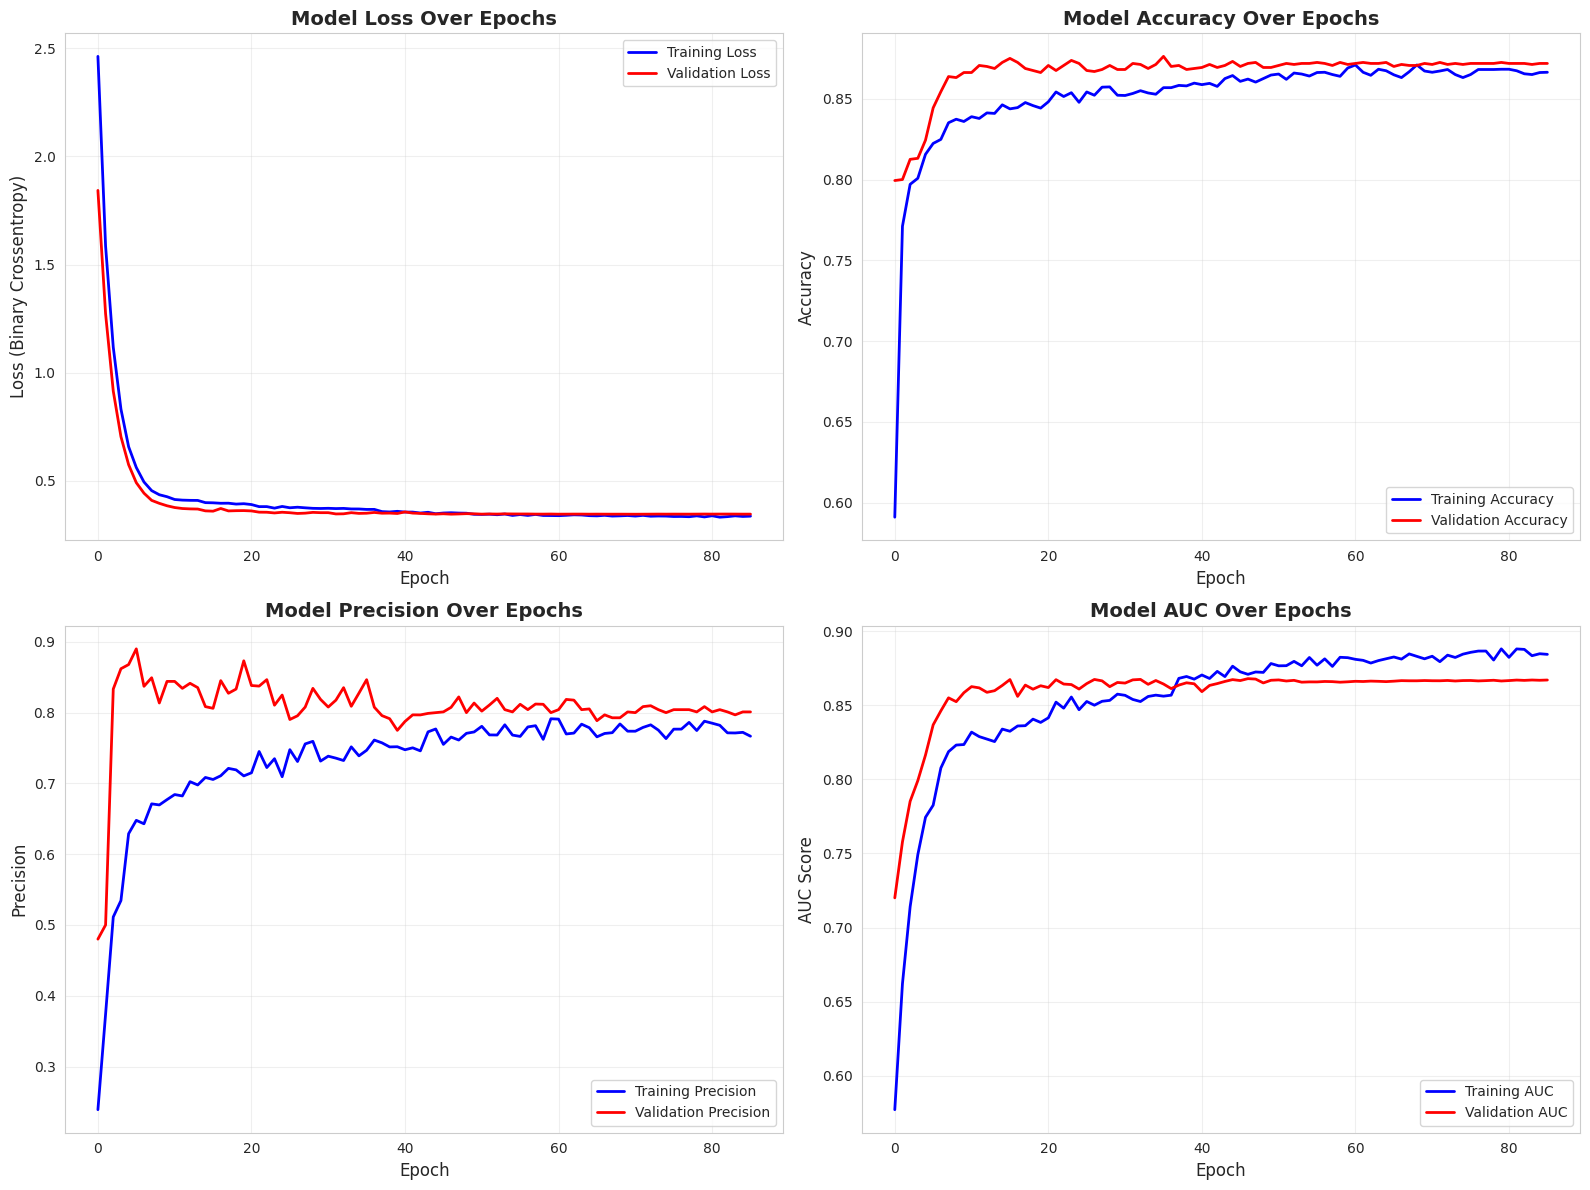


✓ Training history plots saved as 'training_history.png'

MODEL EVALUATION

Test Set Performance:
  Loss: 0.3588
  Accuracy: 0.8620 (86.20%)
  Precision: 0.7885
  Recall: 0.4398
  AUC: 0.8591
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

--------------------------------------------------------------------------------
DETAILED CLASSIFICATION METRICS
--------------------------------------------------------------------------------

Confusion Matrix:
[[1545   48]
 [ 228  179]]

True Negatives (TN): 1545 - Correctly predicted as Retained
False Positives (FP): 48 - Incorrectly predicted as Churned
False Negatives (FN): 228 - Incorrectly predicted as Retained
True Positives (TP): 179 - Correctly predicted as Churned


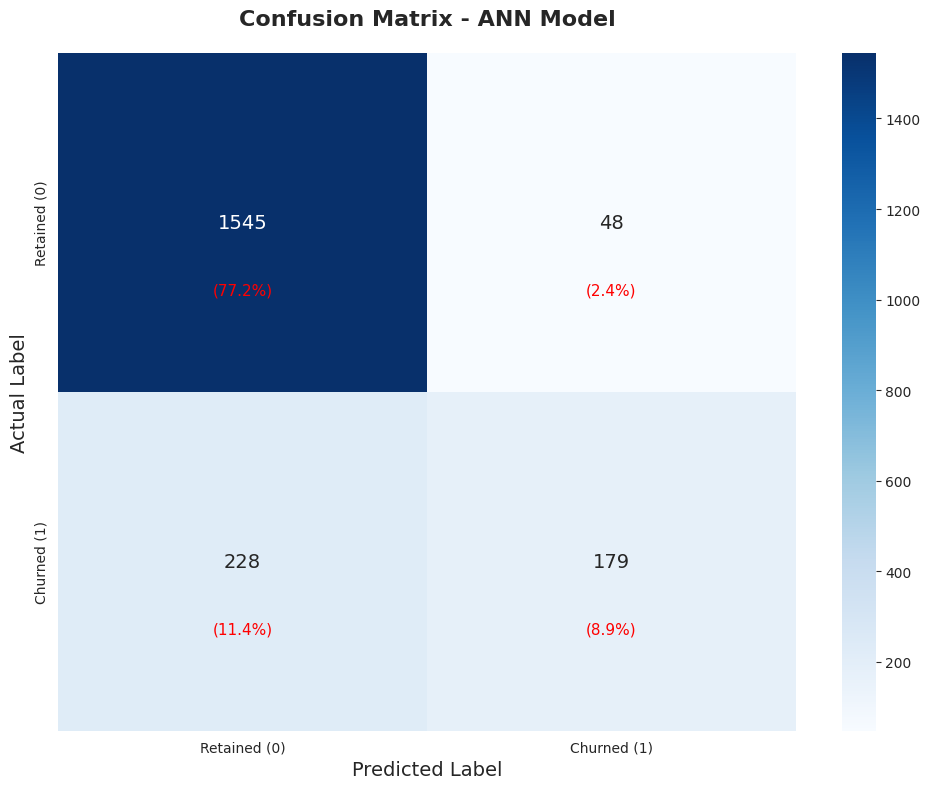


--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

Retained (0)     0.8714    0.9699    0.9180      1593
 Churned (1)     0.7885    0.4398    0.5647       407

    accuracy                         0.8620      2000
   macro avg     0.8300    0.7048    0.7413      2000
weighted avg     0.8545    0.8620    0.8461      2000


F1-Score: 0.5647
Matthews Correlation Coefficient: 0.5200
Specificity: 0.9699

--------------------------------------------------------------------------------
ROC CURVE ANALYSIS
--------------------------------------------------------------------------------


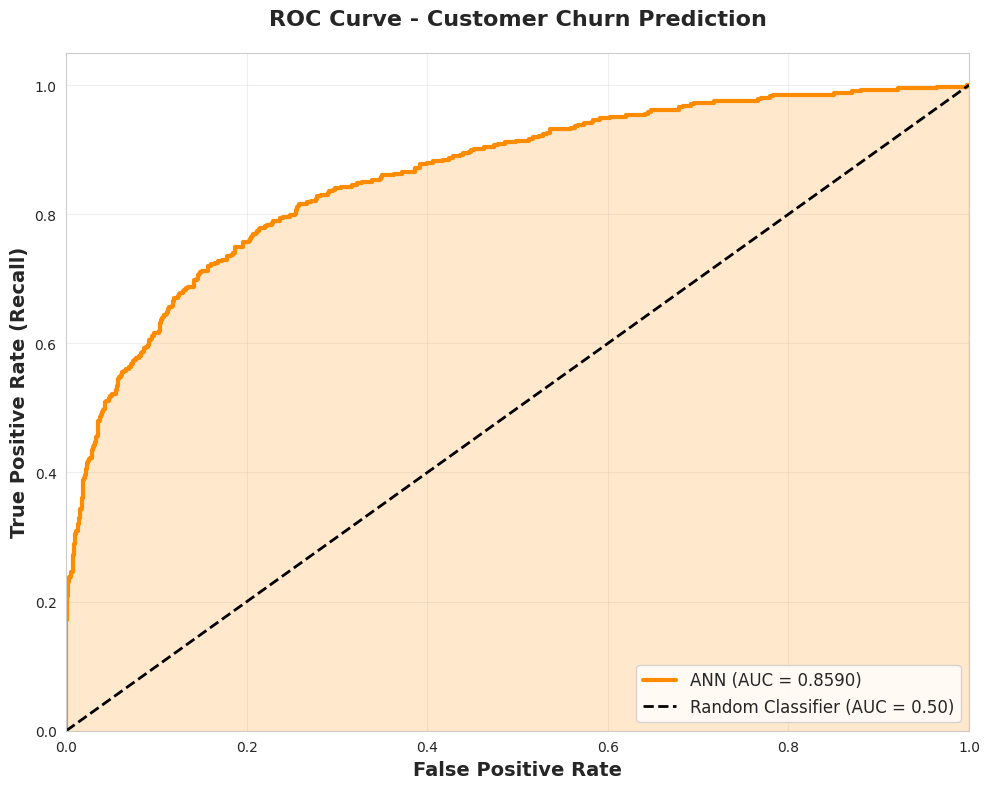


✓ ROC-AUC Score: 0.8590
  Interpretation:
  - AUC > 0.9: Excellent model
  - 0.8 < AUC ≤ 0.9: Good model
  - 0.7 < AUC ≤ 0.8: Fair model
  - AUC ≤ 0.7: Poor model

--------------------------------------------------------------------------------
PRECISION-RECALL CURVE ANALYSIS
--------------------------------------------------------------------------------


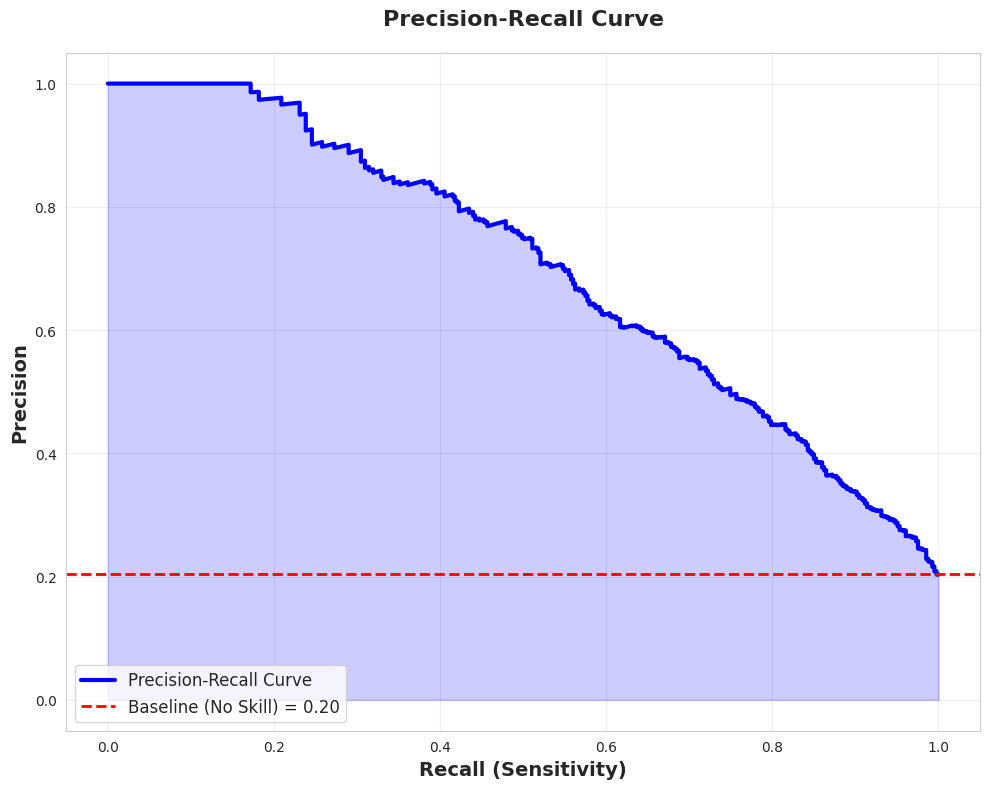


--------------------------------------------------------------------------------
THRESHOLD OPTIMIZATION
--------------------------------------------------------------------------------

Performance at Different Classification Thresholds:
Threshold    Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------
0.3          0.8420       0.6071       0.6339       0.6202      
0.4          0.8610       0.7061       0.5430       0.6139      
0.5          0.8620       0.7885       0.4398       0.5647      
0.6          0.8595       0.8424       0.3808       0.5245      
0.7          0.8500       0.8639       0.3120       0.4585      


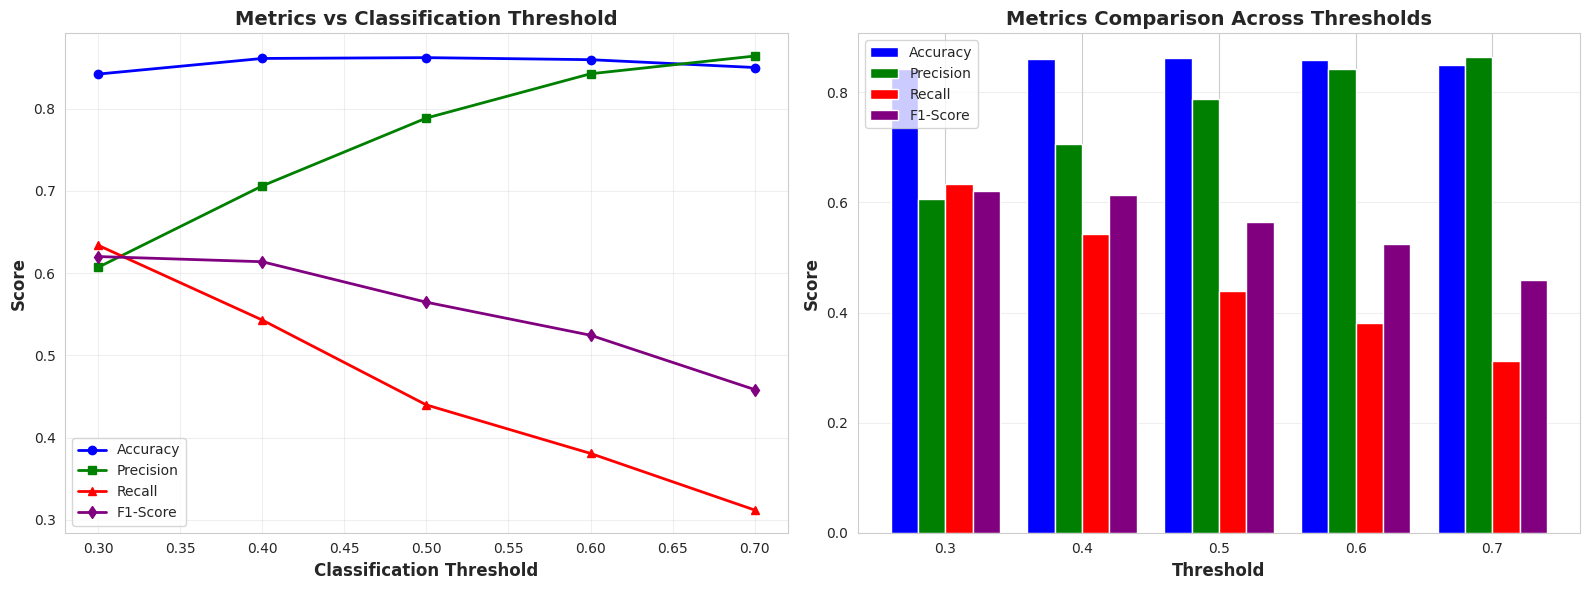


COMPARING DIFFERENT OPTIMIZERS

Training with Adam optimizer...
  Test Accuracy: 0.8675
  Test AUC: 0.8645

Training with SGD optimizer...
  Test Accuracy: 0.8525
  Test AUC: 0.8578

Training with RMSprop optimizer...
  Test Accuracy: 0.8575
  Test AUC: 0.8566


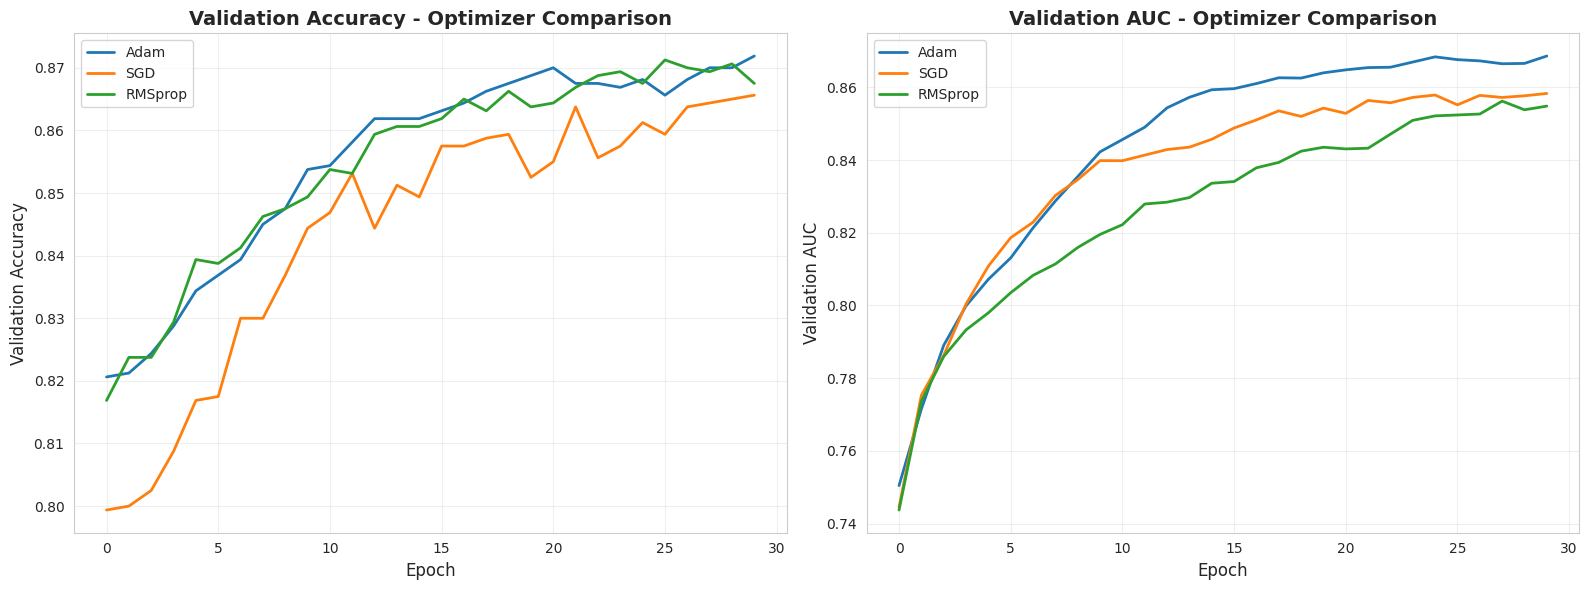


COMPARING DIFFERENT ACTIVATION FUNCTIONS

Training with RELU activation...
  Test Accuracy: 0.8615
  Test AUC: 0.8614

Training with TANH activation...
  Test Accuracy: 0.8655
  Test AUC: 0.8628

Training with ELU activation...
  Test Accuracy: 0.8600
  Test AUC: 0.8629


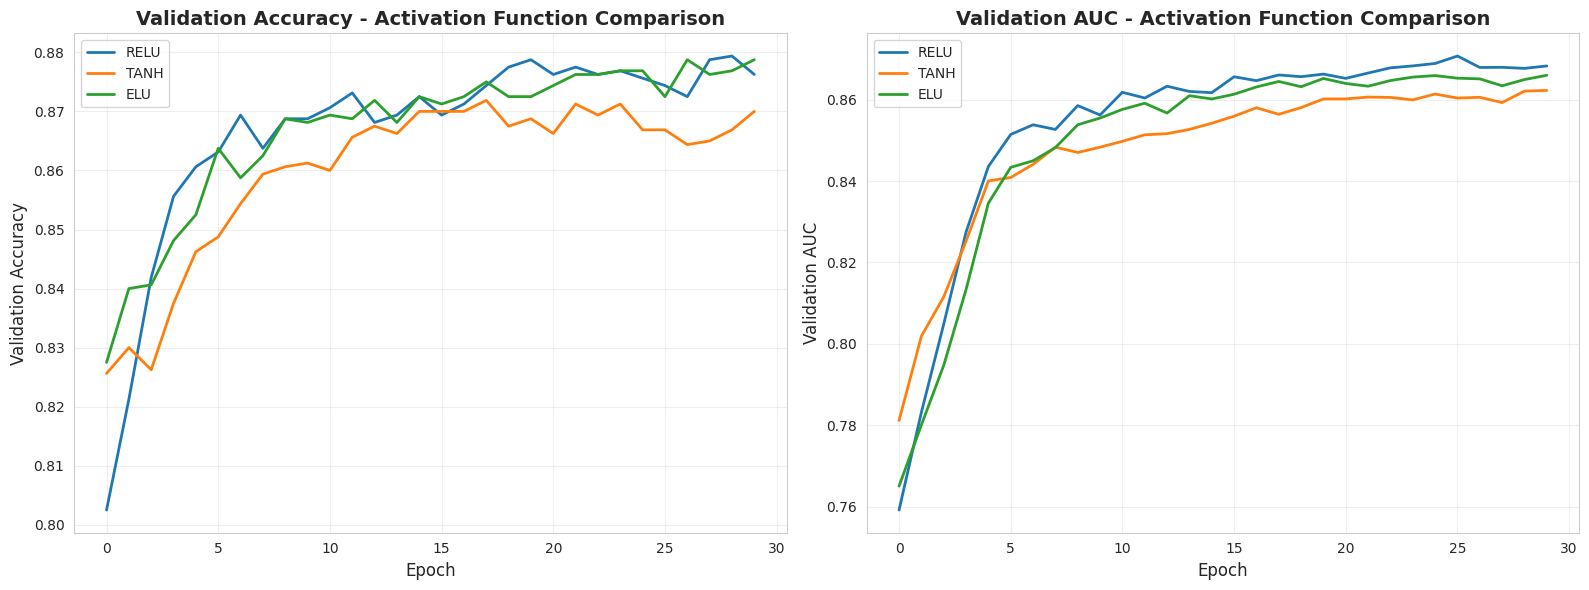


FEATURE IMPORTANCE ANALYSIS

Calculating permutation importance (this may take a moment)...

Feature Importance Ranking:
          feature  importance      std
              Age     0.07265 0.006273
    NumOfProducts     0.06340 0.003254
   IsActiveMember     0.02960 0.004036
Geography_Germany     0.01320 0.002472
          Balance     0.00840 0.002375
  EstimatedSalary     0.00075 0.001662
        HasCrCard     0.00075 0.001401
  Geography_Spain     0.00025 0.001601
           Gender    -0.00030 0.001249
      CreditScore    -0.00180 0.002551
           Tenure    -0.00205 0.001916


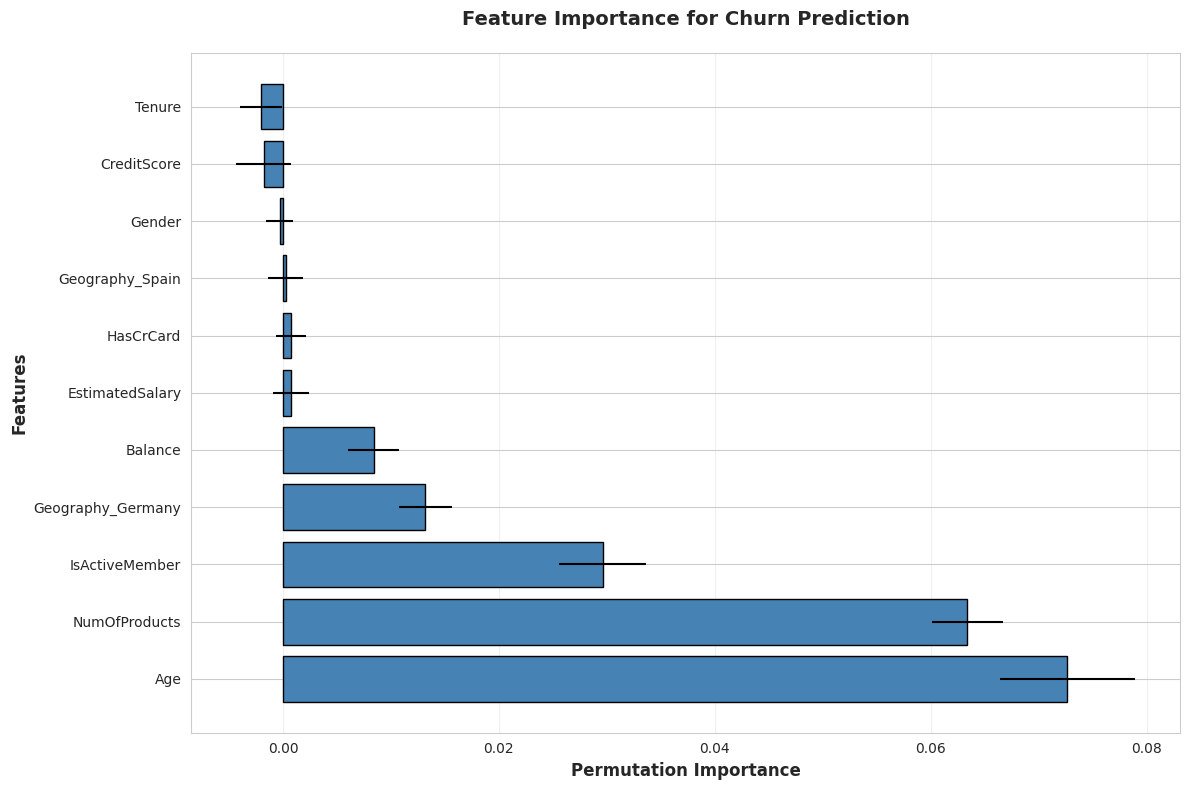


MAKING PREDICTIONS ON NEW DATA

New Customer Data:
   CreditScore Geography  Gender  Age  Tenure  Balance  NumOfProducts  \
0          650    France  Female   35       5   125000              2   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1            80000  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step



Prediction Results:
  Churn Probability: 4.19%
  Prediction: WILL NOT CHURN
  Confidence: 91.6%

SAVING MODEL AND PREPROCESSING OBJECTS
✓ Model saved as 'final_churn_model.h5'
✓ Scaler saved as 'scaler.pkl'
✓ Label encoder saved as 'label_encoder_gender.pkl'

Demonstrating model loading...
✓ Model and preprocessors loaded successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step

Test predictions from loaded model: [0.01462709 0.0358275  0.02868911 0.10479039 0.10685103]

PROJECT SUMMARY AND KEY INSIGHTS

MODEL ARCHITECTURE:
- Input Layer: 11 features
- Hidden Layer 1: 64 neurons (ReLU) + Dropout(0.3) + BatchNorm
- Hidden Layer 2: 32 neurons (ReLU) + Dropout(0.3) + BatchNorm
- Hidden Layer 3: 16 neurons (ReLU) + Dropout(0.2)
- Output Layer: 1 neuron (Sigmoid)
- Total Parameters: 3,585

FINAL PERFORMANCE:
- Test Accuracy: 86.20%
- Test Precision: 0.7885
- Test Recall: 0.4398
- Test AUC: 0.8591
- F1-Score: 0.4585

TOP 5 IMPORTANT FEATURES:

3. Age: 0.0726
6. NumOfProducts: 0.0634
8. IsActiveM

In [9]:
# ============================================================================
# PART 6: BUILDING ARTIFICIAL NEURAL NETWORK (ANN)
# ============================================================================

print("\n" + "="*80)
print("BUILDING ARTIFICIAL NEURAL NETWORK")
print("="*80)

# TensorFlow: Open-source machine learning framework
# Keras: High-level API for building neural networks (now integrated in TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras import regularizers

print(f"TensorFlow version: {tf.__version__}")

# Set random seeds for reproducibility
# Ensures same results across multiple runs
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================================
# ACTIVATION FUNCTIONS EXPLAINED
# ============================================================================

print("\n" + "-"*80)
print("ACTIVATION FUNCTIONS OVERVIEW")
print("-"*80)

activation_info = """
1. ReLU (Rectified Linear Unit): f(x) = max(0, x)
   - Most popular for hidden layers
   - Pros: Simple, fast, helps avoid vanishing gradient
   - Cons: Can suffer from "dying ReLU" problem
   - Use case: Default choice for hidden layers

2. Sigmoid: f(x) = 1 / (1 + e^(-x))
   - Outputs between 0 and 1
   - Pros: Good for binary classification output layer
   - Cons: Vanishing gradient problem, computationally expensive
   - Use case: Binary classification output layer

3. Tanh: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
   - Outputs between -1 and 1
   - Pros: Zero-centered, stronger gradients than sigmoid
   - Cons: Still suffers from vanishing gradient
   - Use case: Hidden layers when zero-centered output is needed

4. Leaky ReLU: f(x) = max(0.01x, x)
   - Variant of ReLU with small negative slope
   - Pros: Solves dying ReLU problem
   - Cons: Inconsistent predictions for negative values
   - Use case: When ReLU causes dead neurons

5. ELU (Exponential Linear Unit): f(x) = x if x>0 else α(e^x - 1)
   - Smooth curve for negative values
   - Pros: Can produce negative outputs, helps with vanishing gradient
   - Cons: Computationally more expensive
   - Use case: Deep networks requiring smooth gradients

6. Softmax: f(x_i) = e^(x_i) / Σ(e^(x_j))
   - Converts logits to probabilities (sum=1)
   - Pros: Multi-class probability distribution
   - Cons: Only for output layer
   - Use case: Multi-class classification output
"""
print(activation_info)

# ============================================================================
# OPTIMIZERS EXPLAINED
# ============================================================================

print("\n" + "-"*80)
print("OPTIMIZERS OVERVIEW")
print("-"*80)

optimizer_info = """
1. SGD (Stochastic Gradient Descent):
   - Update rule: w = w - learning_rate * gradient
   - Pros: Simple, memory efficient
   - Cons: Slow convergence, can get stuck in local minima
   - Hyperparameters: learning_rate, momentum

2. Adam (Adaptive Moment Estimation):
   - Combines RMSprop + Momentum
   - Adapts learning rate for each parameter
   - Pros: Fast convergence, works well with default params
   - Cons: Can sometimes generalize worse than SGD
   - Hyperparameters: learning_rate, beta_1, beta_2

3. RMSprop (Root Mean Square Propagation):
   - Adapts learning rate based on recent gradients
   - Pros: Good for RNNs, handles non-stationary objectives
   - Cons: Requires tuning of learning rate
   - Hyperparameters: learning_rate, rho

4. Adagrad:
   - Adapts learning rate based on parameter history
   - Pros: Good for sparse data
   - Cons: Learning rate can become very small

5. Adadelta:
   - Extension of Adagrad with adaptive learning rate decay
   - Pros: No need to set default learning rate
   - Cons: Can be slow to converge
"""
print(optimizer_info)

# ============================================================================
# MODEL ARCHITECTURE DESIGN
# ============================================================================

print("\n" + "-"*80)
print("DESIGNING ANN ARCHITECTURE")
print("-"*80)

# Get input dimension (number of features)
input_dim = X_train_scaled.shape[1]
print(f"\nInput dimension: {input_dim} features")

# Sequential Model: Linear stack of layers
# Each layer has exactly one input tensor and one output tensor
model = Sequential(name='Customer_Churn_ANN')

# Layer 1: Input + First Hidden Layer
# Dense: Fully connected layer (each neuron connects to all previous layer neurons)
# units=64: Number of neurons in this layer
# activation='relu': ReLU activation function
# input_dim: Number of input features (only needed for first layer)
# kernel_initializer: Weight initialization strategy
#   - 'he_normal': Good for ReLU activation (draws from normal distribution)
# kernel_regularizer: L2 regularization to prevent overfitting
#   - Adds penalty term: λ * Σ(weights²) to loss function
model.add(Dense(units=64,
                activation='relu',
                input_dim=input_dim,
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.01),
                name='Hidden_Layer_1'))

# Dropout Layer: Regularization technique
# Randomly sets input units to 0 with frequency of 'rate' during training
# Helps prevent overfitting by reducing co-adaptation of neurons
# 0.3 means 30% of neurons are dropped during each training step
model.add(Dropout(rate=0.3, name='Dropout_1'))

# Batch Normalization: Normalizes inputs to each layer
# Reduces internal covariate shift
# Benefits: Faster training, higher learning rates, less sensitivity to initialization
model.add(BatchNormalization(name='BatchNorm_1'))

# Layer 2: Second Hidden Layer
# Fewer neurons than first layer (common pattern: funnel architecture)
model.add(Dense(units=32,
                activation='relu',
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.01),
                name='Hidden_Layer_2'))

model.add(Dropout(rate=0.3, name='Dropout_2'))
model.add(BatchNormalization(name='BatchNorm_2'))

# Layer 3: Third Hidden Layer
# Further reduction in neurons
model.add(Dense(units=16,
                activation='relu',
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.01),
                name='Hidden_Layer_3'))

model.add(Dropout(rate=0.2, name='Dropout_3'))

# Output Layer: Final prediction layer
# units=1: Single output (binary classification)
# activation='sigmoid': Outputs probability between 0 and 1
#   - Output > 0.5 → Class 1 (Churned)
#   - Output ≤ 0.5 → Class 0 (Retained)
model.add(Dense(units=1,
                activation='sigmoid',
                name='Output_Layer'))

# Model Summary: Display architecture details
print("\n" + "="*80)
print("MODEL ARCHITECTURE")
print("="*80)
model.summary()

# Calculate total parameters

trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

print(f"\nTotal Trainable Parameters: {trainable_params:,}")

# Visualize model architecture
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # Top to Bottom
    dpi=96
)
print("\n✓ Model architecture saved as 'model_architecture.png'")

# ============================================================================
# MODEL COMPILATION
# ============================================================================

print("\n" + "-"*80)
print("COMPILING MODEL")
print("-"*80)

# Optimizer: Adam with custom learning rate
# learning_rate=0.001: Step size for weight updates (default for Adam)
# Lower values: More precise but slower training
# Higher values: Faster but might overshoot optimal weights
optimizer = Adam(learning_rate=0.001)

# Loss function: Binary Crossentropy
# Measures difference between predicted probabilities and actual labels
# Formula: -[y*log(ŷ) + (1-y)*log(1-ŷ)]
# Perfect for binary classification with sigmoid output
loss_function = 'binary_crossentropy'

# Metrics: Additional measures to monitor during training
# - accuracy: Percentage of correct predictions
# - Precision: TP / (TP + FP) - How many predicted positives are actually positive
# - Recall: TP / (TP + FN) - How many actual positives are captured
# - AUC: Area Under ROC Curve - Overall model performance measure
metrics = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

# Compile: Configures model for training
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=metrics
)

print(f"✓ Optimizer: {optimizer.__class__.__name__} (lr={optimizer.learning_rate.numpy()})")
print(f"✓ Loss Function: {loss_function}")
print(f"✓ Metrics: {[m if isinstance(m, str) else m.name for m in metrics]}")

# ============================================================================
# CALLBACKS FOR TRAINING OPTIMIZATION
# ============================================================================

print("\n" + "-"*80)
print("SETTING UP CALLBACKS")
print("-"*80)

# Callback 1: Early Stopping
# Stops training when monitored metric stops improving
# Prevents overfitting and saves training time
early_stopping = EarlyStopping(
    monitor='val_loss',          # Metric to monitor
    patience=15,                  # Number of epochs with no improvement to wait
    restore_best_weights=True,   # Restore weights from best epoch
    verbose=1,                   # Print messages
    mode='min'                   # 'min' because we want to minimize loss
)
print("✓ Early Stopping: Monitors val_loss, patience=15")

# Callback 2: Learning Rate Reduction
# Reduces learning rate when metric plateaus
# Helps fine-tune weights in later epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',      # Metric to monitor
    factor=0.5,             # New_lr = lr * factor
    patience=5,             # Epochs with no improvement before reducing
    min_lr=1e-7,           # Lower bound on learning rate
    verbose=1,
    mode='min'
)
print("✓ Learning Rate Reduction: factor=0.5, patience=5")

# Callback 3: Model Checkpoint
# Saves model after every epoch with improvement
model_checkpoint = ModelCheckpoint(
    filepath='best_churn_model.h5',   # File path to save model
    monitor='val_auc',                 # Metric to monitor
    save_best_only=True,              # Only save when metric improves
    mode='max',                       # 'max' because higher AUC is better
    verbose=1
)
print("✓ Model Checkpoint: Saves best model based on val_auc")

# Combine all callbacks
callbacks = [early_stopping, reduce_lr, model_checkpoint]

# ============================================================================
# MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("TRAINING NEURAL NETWORK")
print("="*80)

# fit(): Trains the model on training data
history = model.fit(
    X_train_scaled,              # Training features
    y_train,                     # Training labels
    epochs=100,                  # Maximum number of complete passes through training data
    batch_size=32,              # Number of samples per gradient update
                                # Smaller: More updates, more noise, slower
                                # Larger: Fewer updates, less noise, faster
    validation_split=0.2,       # Use 20% of training data for validation
                                # Validation data is used to tune hyperparameters
    callbacks=callbacks,        # Apply callbacks during training
    verbose=1,                  # Display progress bar
    shuffle=True               # Shuffle training data before each epoch
)

print("\n✓ Training completed!")

# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("TRAINING HISTORY VISUALIZATION")
print("="*80)

# Extract history metrics
# history.history: Dictionary containing metrics for each epoch
history_dict = history.history

# Plot 1: Loss Curves (Training vs Validation)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss
axes[0, 0].plot(history_dict['loss'], label='Training Loss', linewidth=2, color='blue')
axes[0, 0].plot(history_dict['val_loss'], label='Validation Loss', linewidth=2, color='red')
axes[0, 0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history_dict['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
axes[0, 1].plot(history_dict['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
axes[0, 1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history_dict['precision'], label='Training Precision', linewidth=2, color='blue')
axes[1, 0].plot(history_dict['val_precision'], label='Validation Precision', linewidth=2, color='red')
axes[1, 0].set_title('Model Precision Over Epochs', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# AUC
axes[1, 1].plot(history_dict['auc'], label='Training AUC', linewidth=2, color='blue')
axes[1, 1].plot(history_dict['val_auc'], label='Validation AUC', linewidth=2, color='red')
axes[1, 1].set_title('Model AUC Over Epochs', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('AUC Score', fontsize=12)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training history plots saved as 'training_history.png'")

# ============================================================================
# MODEL EVALUATION ON TEST SET
# ============================================================================

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# evaluate(): Returns loss and metrics on test data
# Does not update model weights (inference mode)
test_results = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\nTest Set Performance:")
print(f"  Loss: {test_results[0]:.4f}")
print(f"  Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
print(f"  Precision: {test_results[2]:.4f}")
print(f"  Recall: {test_results[3]:.4f}")
print(f"  AUC: {test_results[4]:.4f}")

# Make predictions on test set
# predict(): Generates output predictions for input samples
# Returns probabilities for sigmoid activation (values between 0 and 1)
y_pred_prob = model.predict(X_test_scaled).ravel()

# Convert probabilities to binary predictions
# Threshold = 0.5 (standard for binary classification)
y_pred = (y_pred_prob > 0.5).astype(int)

# ============================================================================
# COMPREHENSIVE PERFORMANCE METRICS
# ============================================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    matthews_corrcoef
)

print("\n" + "-"*80)
print("DETAILED CLASSIFICATION METRICS")
print("-"*80)

# Confusion Matrix: 2x2 table showing prediction results
# [[TN, FP],
#  [FN, TP]]
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN): {cm[0, 0]} - Correctly predicted as Retained")
print(f"False Positives (FP): {cm[0, 1]} - Incorrectly predicted as Churned")
print(f"False Negatives (FN): {cm[1, 0]} - Incorrectly predicted as Retained")
print(f"True Positives (TP): {cm[1, 1]} - Correctly predicted as Churned")

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'],
            annot_kws={'fontsize': 14})
plt.title('Confusion Matrix - ANN Model', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                ha='center', va='center', fontsize=11, color='red')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report: Comprehensive metrics per class
# Precision: TP / (TP + FP) - Accuracy of positive predictions
# Recall (Sensitivity): TP / (TP + FN) - Coverage of actual positives
# F1-Score: 2 * (Precision * Recall) / (Precision + Recall) - Harmonic mean
# Support: Number of actual occurrences in dataset
print("\n" + "-"*80)
print("CLASSIFICATION REPORT")
print("-"*80)
print(classification_report(y_test, y_pred,
                          target_names=['Retained (0)', 'Churned (1)'],
                          digits=4))

# Additional Metrics

# F1-Score: Balance between precision and recall
f1 = f1_score(y_test, y_pred)
print(f"\nF1-Score: {f1:.4f}")

# Matthews Correlation Coefficient: Balanced measure for imbalanced classes
# Range: -1 (total disagreement) to +1 (perfect prediction)
# 0 = random prediction
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

# Specificity: TN / (TN + FP) - How well model identifies negatives
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
print(f"Specificity: {specificity:.4f}")

# ============================================================================
# ROC CURVE AND AUC
# ============================================================================

print("\n" + "-"*80)
print("ROC CURVE ANALYSIS")
print("-"*80)

# ROC (Receiver Operating Characteristic) Curve
# Plots True Positive Rate (Recall) vs False Positive Rate
# Shows trade-off between sensitivity and specificity
# FPR = FP / (FP + TN)
# TPR = TP / (TP + FN)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# AUC (Area Under Curve): Single number summarizing ROC curve
# AUC = 1.0: Perfect classifier
# AUC = 0.5: Random classifier
# AUC < 0.5: Worse than random
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f'ANN (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Customer Churn Prediction', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ ROC-AUC Score: {auc_score:.4f}")
print("  Interpretation:")
print("  - AUC > 0.9: Excellent model")
print("  - 0.8 < AUC ≤ 0.9: Good model")
print("  - 0.7 < AUC ≤ 0.8: Fair model")
print("  - AUC ≤ 0.7: Poor model")

# ============================================================================
# PRECISION-RECALL CURVE
# ============================================================================

print("\n" + "-"*80)
print("PRECISION-RECALL CURVE ANALYSIS")
print("-"*80)

# Precision-Recall Curve: Useful for imbalanced datasets
# Shows trade-off between precision and recall
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, linewidth=3, color='blue', label='Precision-Recall Curve')
plt.fill_between(recall, precision, alpha=0.2, color='blue')

plt.xlabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=12)

# Add baseline (proportion of positive class)
baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', linewidth=2,
           label=f'Baseline (No Skill) = {baseline:.2f}')
plt.legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

from sklearn.metrics import precision_score, recall_score, f1_score
# ============================================================================
# THRESHOLD OPTIMIZATION
# ============================================================================

print("\n" + "-"*80)
print("THRESHOLD OPTIMIZATION")
print("-"*80)

# Different thresholds for different business needs
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

print("\nPerformance at Different Classification Thresholds:")
print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

threshold_results = []
for threshold in thresholds_to_test:
    y_pred_thresh = (y_pred_prob > threshold).astype(int).ravel()

    acc = (y_pred_thresh == y_test).mean()
    prec = precision_score(y_test, y_pred_thresh) if y_pred_thresh.sum() > 0 else 0
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    threshold_results.append({
        'threshold': threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })

    print(f"{threshold:<12.1f} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

from sklearn.metrics import precision_score, recall_score

# Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_df = pd.DataFrame(threshold_results)

axes[0].plot(metrics_df['threshold'], metrics_df['accuracy'],
            marker='o', linewidth=2, label='Accuracy', color='blue')
axes[0].plot(metrics_df['threshold'], metrics_df['precision'],
            marker='s', linewidth=2, label='Precision', color='green')
axes[0].plot(metrics_df['threshold'], metrics_df['recall'],
            marker='^', linewidth=2, label='Recall', color='red')
axes[0].plot(metrics_df['threshold'], metrics_df['f1_score'],
            marker='d', linewidth=2, label='F1-Score', color='purple')
axes[0].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Metrics vs Classification Threshold', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Bar chart comparison
x = np.arange(len(thresholds_to_test))
width = 0.2

axes[1].bar(x - 1.5*width, metrics_df['accuracy'], width, label='Accuracy', color='blue')
axes[1].bar(x - 0.5*width, metrics_df['precision'], width, label='Precision', color='green')
axes[1].bar(x + 0.5*width, metrics_df['recall'], width, label='Recall', color='red')
axes[1].bar(x + 1.5*width, metrics_df['f1_score'], width, label='F1-Score', color='purple')

axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics Comparison Across Thresholds', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{t:.1f}' for t in thresholds_to_test])
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# COMPARING DIFFERENT OPTIMIZERS
# ============================================================================

print("\n" + "="*80)
print("COMPARING DIFFERENT OPTIMIZERS")
print("="*80)

# Test multiple optimizers to find best performance
optimizers_to_test = {
    'Adam': Adam(learning_rate=0.001),
    'SGD': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001)
}

optimizer_results = {}

for opt_name, optimizer in optimizers_to_test.items():
    print(f"\nTraining with {opt_name} optimizer...")

    # Create new model with same architecture
    model_opt = Sequential([
        Dense(64, activation='relu', input_dim=input_dim, kernel_initializer='he_normal'),
        Dropout(0.3),
        BatchNormalization(),
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.3),
        BatchNormalization(),
        Dense(16, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model_opt.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    # Train with fewer epochs for comparison
    history_opt = model_opt.fit(
        X_train_scaled, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=0,
        shuffle=True
    )

    # Evaluate
    test_loss, test_acc, test_auc = model_opt.evaluate(X_test_scaled, y_test, verbose=0)

    optimizer_results[opt_name] = {
        'history': history_opt.history,
        'test_accuracy': test_acc,
        'test_auc': test_auc
    }

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test AUC: {test_auc:.4f}")

# Visualize optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for opt_name, results in optimizer_results.items():
    axes[0].plot(results['history']['val_accuracy'], label=opt_name, linewidth=2)
    axes[1].plot(results['history']['val_auc'], label=opt_name, linewidth=2)

axes[0].set_title('Validation Accuracy - Optimizer Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation AUC - Optimizer Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation AUC', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# COMPARING DIFFERENT ACTIVATION FUNCTIONS
# ============================================================================

print("\n" + "="*80)
print("COMPARING DIFFERENT ACTIVATION FUNCTIONS")
print("="*80)

# Test different activation functions for hidden layers
activations_to_test = ['relu', 'tanh', 'elu']

activation_results = {}

for activation in activations_to_test:
    print(f"\nTraining with {activation.upper()} activation...")

    model_act = Sequential([
        Dense(64, activation=activation, input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation=activation),
        Dropout(0.3),
        Dense(16, activation=activation),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model_act.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    history_act = model_act.fit(
        X_train_scaled, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=0,
        shuffle=True
    )

    test_loss, test_acc, test_auc = model_act.evaluate(X_test_scaled, y_test, verbose=0)

    activation_results[activation] = {
        'history': history_act.history,
        'test_accuracy': test_acc,
        'test_auc': test_auc
    }

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test AUC: {test_auc:.4f}")

# Visualize activation function comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for act_name, results in activation_results.items():
    axes[0].plot(results['history']['val_accuracy'], label=act_name.upper(), linewidth=2)
    axes[1].plot(results['history']['val_auc'], label=act_name.upper(), linewidth=2)

axes[0].set_title('Validation Accuracy - Activation Function Comparison',
                 fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation AUC - Activation Function Comparison',
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation AUC', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# For neural networks, we'll use permutation importance
# Measures importance by randomly shuffling feature and measuring performance drop
from sklearn.inspection import permutation_importance

# Create wrapper for sklearn's permutation_importance
class KerasClassifierWrapper:

    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])  # Required for some sklearn functions

    def fit(self, X, y):
        """
        Dummy fit method - model is already trained.
        Required by sklearn's permutation_importance.
        """
        # We don't actually fit here - model is pre-trained
        # This is just to satisfy sklearn's interface requirement
        return self

    def predict(self, X):
        """
        Make binary predictions.
        """
        proba = self.model.predict(X, verbose=0)
        return (proba > 0.5).astype(int).ravel()

    def predict_proba(self, X):
        """
        Return probability predictions.
        """
        proba = self.model.predict(X, verbose=0).ravel()
        # Return shape (n_samples, 2) for sklearn compatibility
        return np.column_stack([1 - proba, proba])

    def score(self, X, y):
        """
        Return accuracy score.
        """
        predictions = self.predict(X)
        return (predictions == np.array(y).ravel()).mean()

wrapped_model = KerasClassifierWrapper(model)

print("\nCalculating permutation importance (this may take a moment)...")
perm_importance = permutation_importance(
    wrapped_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_importance_df)), feature_importance_df['importance'],
         xerr=feature_importance_df['std'], color='steelblue', edgecolor='black')
plt.yticks(range(len(feature_importance_df)), feature_importance_df['feature'])
plt.xlabel('Permutation Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Feature Importance for Churn Prediction', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PREDICTION ON NEW DATA (EXAMPLE)
# ============================================================================

print("\n" + "="*80)
print("MAKING PREDICTIONS ON NEW DATA")
print("="*80)

# Example: Predict for a new customer
new_customer = pd.DataFrame({
    'CreditScore': [650],
    'Geography': ['France'],
    'Gender': ['Female'],
    'Age': [35],
    'Tenure': [5],
    'Balance': [125000],
    'NumOfProducts': [2],
    'HasCrCard': [1],
    'IsActiveMember': [1],
    'EstimatedSalary': [80000]
})

print("\nNew Customer Data:")
print(new_customer)

# Preprocess new data (same steps as training data)
new_customer['Gender'] = label_encoder_gender.transform(new_customer['Gender'])
new_customer = pd.get_dummies(new_customer, columns=['Geography'], drop_first=True)

# Ensure all columns from training are present
for col in X.columns:
    if col not in new_customer.columns:
        new_customer[col] = 0

# Reorder columns to match training data
new_customer = new_customer[X.columns]

# Scale features
new_customer_scaled = scaler.transform(new_customer)

# Make prediction
churn_probability = model.predict(new_customer_scaled)[0][0]
churn_prediction = 'WILL CHURN' if churn_probability > 0.5 else 'WILL NOT CHURN'

print(f"\nPrediction Results:")
print(f"  Churn Probability: {churn_probability:.2%}")
print(f"  Prediction: {churn_prediction}")
print(f"  Confidence: {abs(churn_probability - 0.5) * 200:.1f}%")

# ============================================================================
# MODEL SAVING AND LOADING
# ============================================================================

print("\n" + "="*80)
print("SAVING MODEL AND PREPROCESSING OBJECTS")
print("="*80)

# Save the trained model
model.save('final_churn_model.h5')
print("✓ Model saved as 'final_churn_model.h5'")

# Save preprocessing objects using joblib
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder_gender, 'label_encoder_gender.pkl')
print("✓ Scaler saved as 'scaler.pkl'")
print("✓ Label encoder saved as 'label_encoder_gender.pkl'")

# Demonstrate loading
print("\nDemonstrating model loading...")
loaded_model = keras.models.load_model('final_churn_model.h5')
loaded_scaler = joblib.load('scaler.pkl')
loaded_label_encoder = joblib.load('label_encoder_gender.pkl')
print("✓ Model and preprocessors loaded successfully")

# Verify loaded model works
test_prediction = loaded_model.predict(X_test_scaled[:5])
print(f"\nTest predictions from loaded model: {test_prediction.ravel()}")

# ============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("\n" + "="*80)
print("PROJECT SUMMARY AND KEY INSIGHTS")
print("="*80)

summary = f"""
MODEL ARCHITECTURE:
- Input Layer: {input_dim} features
- Hidden Layer 1: 64 neurons (ReLU) + Dropout(0.3) + BatchNorm
- Hidden Layer 2: 32 neurons (ReLU) + Dropout(0.3) + BatchNorm
- Hidden Layer 3: 16 neurons (ReLU) + Dropout(0.2)
- Output Layer: 1 neuron (Sigmoid)
- Total Parameters: {trainable_params:,}

FINAL PERFORMANCE:
- Test Accuracy: {test_results[1]*100:.2f}%
- Test Precision: {test_results[2]:.4f}
- Test Recall: {test_results[3]:.4f}
- Test AUC: {test_results[4]:.4f}
- F1-Score: {f1:.4f}

TOP 5 IMPORTANT FEATURES:
"""

for idx, row in feature_importance_df.head().iterrows():
    summary += f"\n{idx+1}. {row['feature']}: {row['importance']:.4f}"

summary += f"""

KEY FINDINGS:
1. The model achieved {test_results[1]*100:.1f}% accuracy on unseen data
2. AUC score of {test_results[4]:.3f} indicates {'excellent' if test_results[4] > 0.9 else 'good'} discriminative ability
3. {feature_importance_df.iloc[0]['feature']} is the most important predictor of churn
4. The model shows {'balanced' if abs(test_results[2] - test_results[3]) < 0.1 else 'imbalanced'} precision-recall trade-off

RECOMMENDATIONS:
1. Monitor customers with high churn probability for retention campaigns
2. Focus on improving {feature_importance_df.iloc[0]['feature']} for at-risk customers
3. Consider ensemble methods or hyperparameter tuning for further improvements
4. Implement regular model retraining with new data to maintain performance
5. Use threshold optimization based on business costs of false positives vs false negatives

FILES GENERATED:
- final_churn_model.h5: Trained neural network model
- scaler.pkl: Feature scaler for preprocessing
- label_encoder_gender.pkl: Gender encoder
- model_architecture.png: Visual model architecture
- training_history.png: Training metrics over epochs
- confusion_matrix.png: Prediction results visualization
- roc_curve.png: ROC curve analysis
- precision_recall_curve.png: Precision-recall trade-off
- threshold_optimization.png: Threshold analysis
- optimizer_comparison.png: Optimizer performance comparison
- activation_comparison.png: Activation function comparison
- feature_importance.png: Feature importance ranking
"""

print(summary)

print("\n" + "="*80)
print("COMPLETE! All analyses finished successfully.")
print("="*80)

# ============================================================================
# ADDITIONAL LEARNING RESOURCES
# ============================================================================

learning_resources = """


CONCEPTS COVERED IN THIS PROJECT:

1. DATA PREPROCESSING:
   - Handling categorical variables (Label Encoding, One-Hot Encoding)
   - Feature scaling (Standardization, Normalization, Robust Scaling)
   - Train-test splitting with stratification

2. NEURAL NETWORK ARCHITECTURE:
   - Sequential model design
   - Dense (Fully Connected) layers
   - Activation functions (ReLU, Sigmoid, Tanh, ELU)
   - Dropout for regularization
   - Batch Normalization for faster training

3. TRAINING TECHNIQUES:
   - Optimizers (Adam, SGD, RMSprop)
   - Loss functions (Binary Crossentropy)
   - Callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
   - Batch processing and epochs

4. EVALUATION METRICS:
   - Confusion Matrix
   - Accuracy, Precision, Recall, F1-Score
   - ROC Curve and AUC
   - Precision-Recall Curve
   - Matthews Correlation Coefficient

5. ADVANCED TOPICS:
   - Hyperparameter tuning
   - Threshold optimization
   - Feature importance analysis
   - Model comparison (optimizers, activations)



=================================================================================
"""
